# Clase: Segmentación de Clientes con Análisis Multivariable y Clustering

**Duración:** 1 hora 40 minutos
**Módulo:** Identificación de variables clave de rentabilidad y segmentación de clientes
**Objetivo:** Identificar segmentos de clientes a partir de datos reales y proponer acciones para incrementar el valor de la empresa.

---

## Contexto del Caso: Gabu

Gabu es una startup que ofrece supervisión a niños mientras juegan online. Busca entender mejor a sus clientes para personalizar campañas de adquisición y reducir la cancelación (churn).

* **Variables del dataset:**

  * Edad del niño (`kids_age`)
  * Sexo del niño (`kids_sex`: 0=niño, 1=niña)
  * Ingreso familiar (`family_income`)
  * Tiempo promedio de sesión (`avg_session_time`)
  * Mensualidad (`monthly_fee`), tipo de suscripción, tenure, churn, etc.

---

## Estructura de la Sesión

1. Introducción y motivación
2. Preparación y limpieza de datos
3. Clustering y visualización
4. Interpretación de segmentos y acción de negocio
5. Cierre y reflexión

---

## 1. Introducción y Motivación (20 min)

* ¿Por qué segmentar clientes? Beneficios para retención y adquisición.
* ¿Qué es análisis multivariable y clustering? Ejemplos en la industria.
* Demostración visual rápida con datos sintéticos:

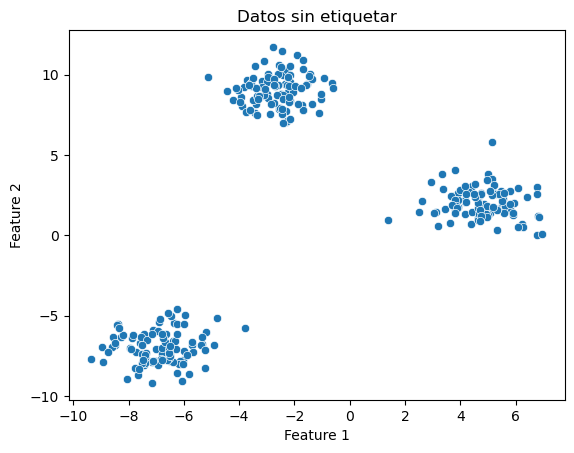

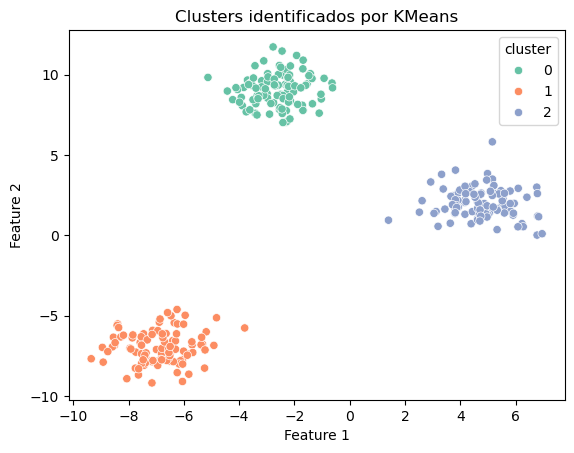

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X_blob, y_blob = make_blobs(n_samples=300, centers=3, random_state=42)
df_blob = pd.DataFrame(X_blob, columns=["Feature 1", "Feature 2"])

sns.scatterplot(x="Feature 1", y="Feature 2", data=df_blob)
plt.title("Datos sin etiquetar")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
df_blob["cluster"] = kmeans.fit_predict(df_blob)

sns.scatterplot(x="Feature 1", y="Feature 2", hue="cluster", data=df_blob, palette="Set2")
plt.title("Clusters identificados por KMeans")
plt.show()

**Discusión:** ¿Qué representa cada grupo? ¿Cómo se decide el número de clusters?

---

## 2. Preparación y Limpieza de Datos (20 min)

* Revisión inicial y selección de variables relevantes:

  * `kids_age`, `kids_sex`, `family_income`, `avg_session_time`

In [2]:
df = pd.read_csv("data/gabu_dataset.csv")
features = ['kids_age', 'kids_sex', 'family_income', 'avg_session_time']
df[features].describe()
df[features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1317 entries, 0 to 1316
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kids_age          1317 non-null   int64  
 1   kids_sex          1317 non-null   int64  
 2   family_income     1307 non-null   float64
 3   avg_session_time  1307 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 41.3 KB


* **Limpieza**:

  * Filtrado de edades fuera de rango
  * Eliminar nulos
  * Eliminar outliers

In [3]:

df_clean = df.copy()
df_clean = df_clean[(df_clean['kids_age'] >= 5) & (df_clean['kids_age'] <= 12)]
df_clean = df_clean[df_clean['kids_sex'].isin([0, 1])]
df_clean = df_clean[df_clean['family_income'].notna()]
df_clean = df_clean[df_clean['avg_session_time'].notna()]

for col in ['kids_age', 'family_income', 'avg_session_time']:
    q_low = df_clean[col].quantile(0.01)
    q_high = df_clean[col].quantile(0.99)
    df_clean = df_clean[(df_clean[col] >= q_low) & (df_clean[col] <= q_high)]

df_clean[features].describe()

,kids_age,kids_sex,family_income,avg_session_time
count,1267.000000,1267.000000,1267.000000,1267.000000
mean,8.967640,0.149171,83938.437253,33.685903
std,1.995982,0.356398,42175.226870,10.006207
min,6.000000,0.000000,25000.000000,9.624021
25%,7.000000,0.000000,50000.000000,26.353231
50%,9.000000,0.000000,75000.000000,33.672648
75%,11.000000,0.000000,100000.000000,40.737260
max,12.000000,1.000000,200000.000000,59.062239


* **Normalización**:

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[["kids_age", "family_income", "avg_session_time"]])
X_cluster = pd.DataFrame(X_scaled, columns=["kids_age", "family_income", "avg_session_time"], index=df_clean.index)
X_cluster["kids_sex"] = df_clean["kids_sex"].values

---

## 3. Clustering y Visualización (30 min)

* **Selección del número de clusters (Elbow method):**

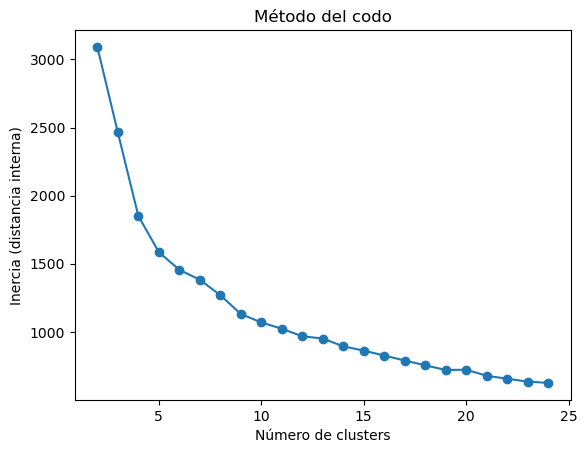

In [5]:
inertia = []
for k in range(2, 25):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_cluster)
    inertia.append(km.inertia_)

plt.plot(range(2, 25), inertia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia (distancia interna)")
plt.title("Método del codo")
plt.show()

* **Aplicar KMeans y PCA:**

In [8]:
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=5, random_state=42)
df_clean['cluster'] = kmeans.fit_predict(X_cluster)

pca = PCA(n_components=3)
df_clean[['pca_1', 'pca_2', 'pca_3']] = pca.fit_transform(X_cluster)

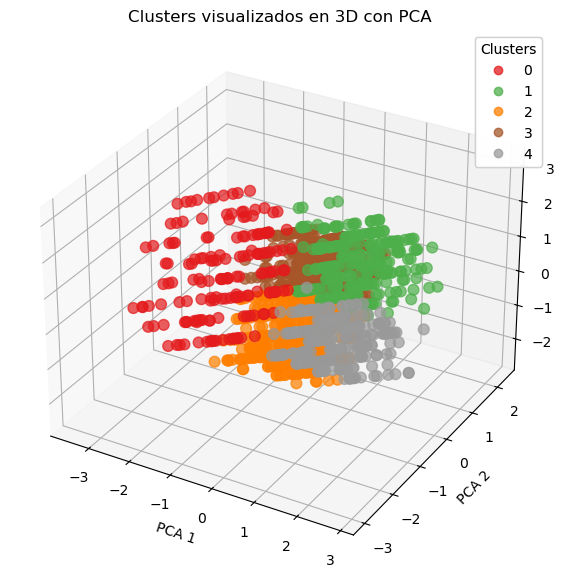

In [9]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_clean['pca_1'],
    df_clean['pca_2'],
    df_clean['pca_3'],
    c=df_clean['cluster'],
    cmap='Set1',
    s=60,
    alpha=0.7
)

ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.set_title('Clusters visualizados en 3D con PCA')

# Leyenda con los clusters
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters", loc='best')
ax.add_artist(legend1)

plt.show()

---

## 4. Interpretación de Segmentos y Acción de Negocio (20 min)

* **Distribución de variables por cluster:**

/var/folders/p_/t355wf8d61177pp2l7_8j9480000gn/T/ipykernel_40892/3637418940.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="cluster", y=feature, palette="Set2")


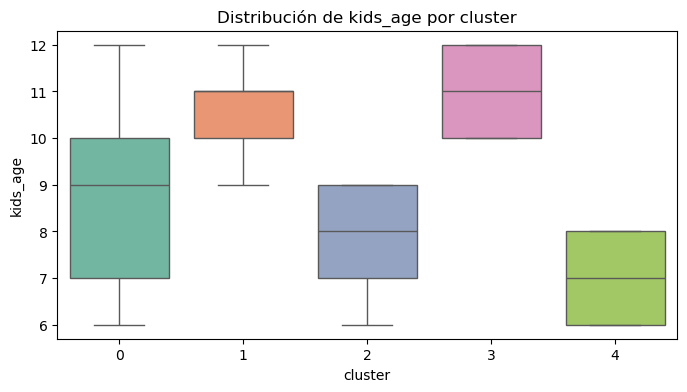

/var/folders/p_/t355wf8d61177pp2l7_8j9480000gn/T/ipykernel_40892/3637418940.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="cluster", y=feature, palette="Set2")


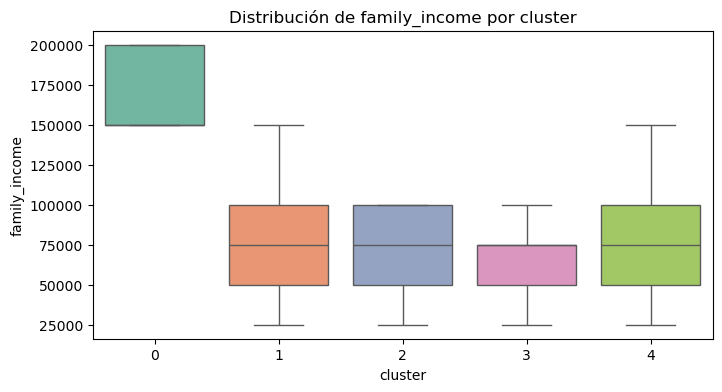

/var/folders/p_/t355wf8d61177pp2l7_8j9480000gn/T/ipykernel_40892/3637418940.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="cluster", y=feature, palette="Set2")


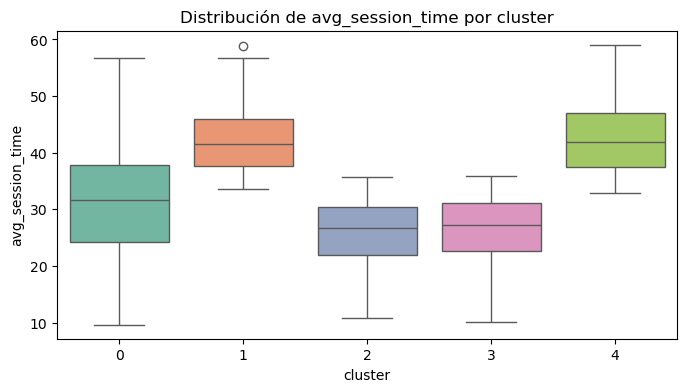

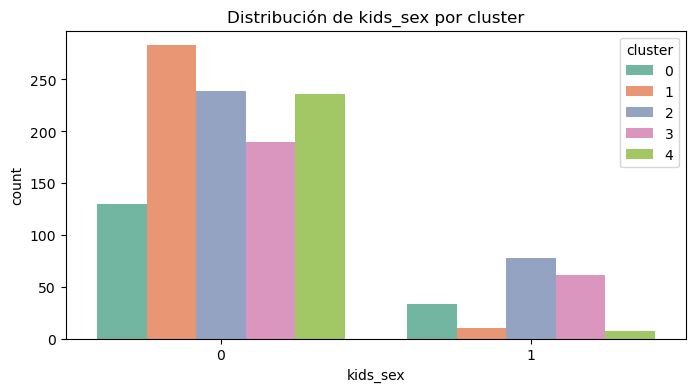

In [10]:
features_to_plot = ["kids_age", "family_income", "avg_session_time", "kids_sex"]
for feature in features_to_plot:
    plt.figure(figsize=(8, 4))
    if feature == "kids_sex":
        sns.countplot(data=df_clean, x=feature, hue="cluster", palette="Set2")
    else:
        sns.boxplot(data=df_clean, x="cluster", y=feature, palette="Set2")
    plt.title(f"Distribución de {feature} por cluster")
    plt.show()

* **Resumen de KPIs por segmento:**

In [11]:
kpi_cols = ['monthly_fee', 'tenure', 'churn', 'customer_support_tickets', 'avg_session_time']
print(df_clean.groupby('cluster')[kpi_cols].mean().round(2))

         monthly_fee  tenure  churn  customer_support_tickets  \
cluster                                                         
0              17.00   12.06   0.34                      2.12   
1              14.73   17.65   0.28                      2.15   
2              15.27    9.32   0.34                      2.15   
3              15.08    9.89   0.37                      2.16   
4              15.34   17.71   0.28                      2.13   

         avg_session_time  
cluster                    
0                   31.22  
1                   42.32  
2                   25.94  
3                   26.33  
4                   42.64  


* **Discusión guiada:**

  * ¿Qué segmentos tienen mayor riesgo de churn?
  * ¿A quién conviene incentivar con promociones?
  * ¿Qué segmento aporta más ingresos?

---

## 5. Cierre y Reflexión (10 min)

* Ventajas del clustering en negocios
* Limitaciones del método
* Alternativas y extensiones (DBSCAN, clustering con embeddings, análisis jerárquico)


---

## Actividad Final para los estudiantes

1. Realiza el proceso de segmentación paso a paso con el dataset real.
2. Interpreta los clusters resultantes y elige el segmento que debería recibir incentivos, justificando por qué.
3. Propón una acción de negocio basada en el análisis de clusters.

---

## Recursos y Referencias

* [Scikit-learn Clustering](https://scikit-learn.org/stable/modules/clustering.html)
* [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
* [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
* [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
